In [2]:
!conda activate 16s-nanopore


CondaError: Run 'conda init' before 'conda activate'



# ITS

## Taxonomic composition of the samples

Plot successfully saved to:
/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/6_plots


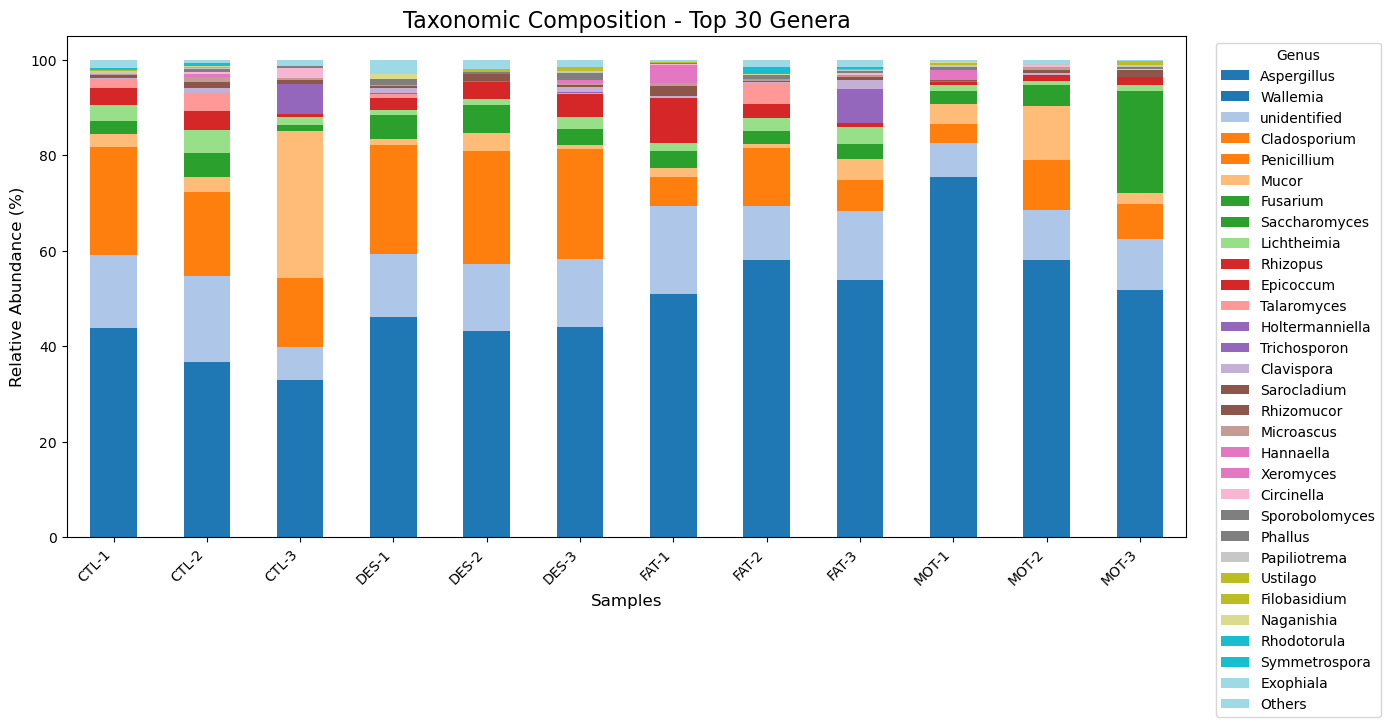

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define INPUT paths (loading the saved tables)
stats_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/5_statistics'
counts_path = os.path.join(stats_dir, 'rarefied_genus_counts.csv')

# Load the counts matrix (index_col=0 keeps the sample names as rows)
counts_rarefied = pd.read_csv(counts_path, index_col=0)

# 2. Define OUTPUT directory for plots
plot_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/6_plots'
os.makedirs(plot_dir, exist_ok=True)

# 3. Convert absolute counts to relative abundance (percentages)
rel_abund = counts_rarefied.div(counts_rarefied.sum(axis=1), axis=0) * 100

# 4. Identify the Top 10 most abundant genera
top_n = 30
top_genera = rel_abund.mean().nlargest(top_n).index

# 5. Create a new dataframe with Top 10 and group the rest into 'Others'
plot_df = rel_abund[top_genera].copy()
plot_df['Others'] = rel_abund.drop(columns=top_genera).sum(axis=1)

# Sort samples alphabetically
plot_df = plot_df.sort_index()

# 6. Plot Stacked Bar Chart
ax = plot_df.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='tab20')

# Formatting the plot
plt.title(f'Taxonomic Composition - Top {top_n} Genera', fontsize=16)
plt.ylabel('Relative Abundance (%)', fontsize=12)
plt.xlabel('Samples', fontsize=12)
plt.legend(title='Genus', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# 7. Save the plot in PNG and SVG
plot_path_png = os.path.join(plot_dir, f'taxonomic_composition_top{top_n}.png')
plot_path_svg = os.path.join(plot_dir, f'taxonomic_composition_top{top_n}.svg')

plt.savefig(plot_path_png, dpi=300, bbox_inches='tight')
plt.savefig(plot_path_svg, bbox_inches='tight')

print(f"Plot successfully saved to:\n{plot_dir}")

# Display the plot in the notebook
plt.show()

## Separation of the samples by groups

Plot successfully saved to:
/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/6_plots


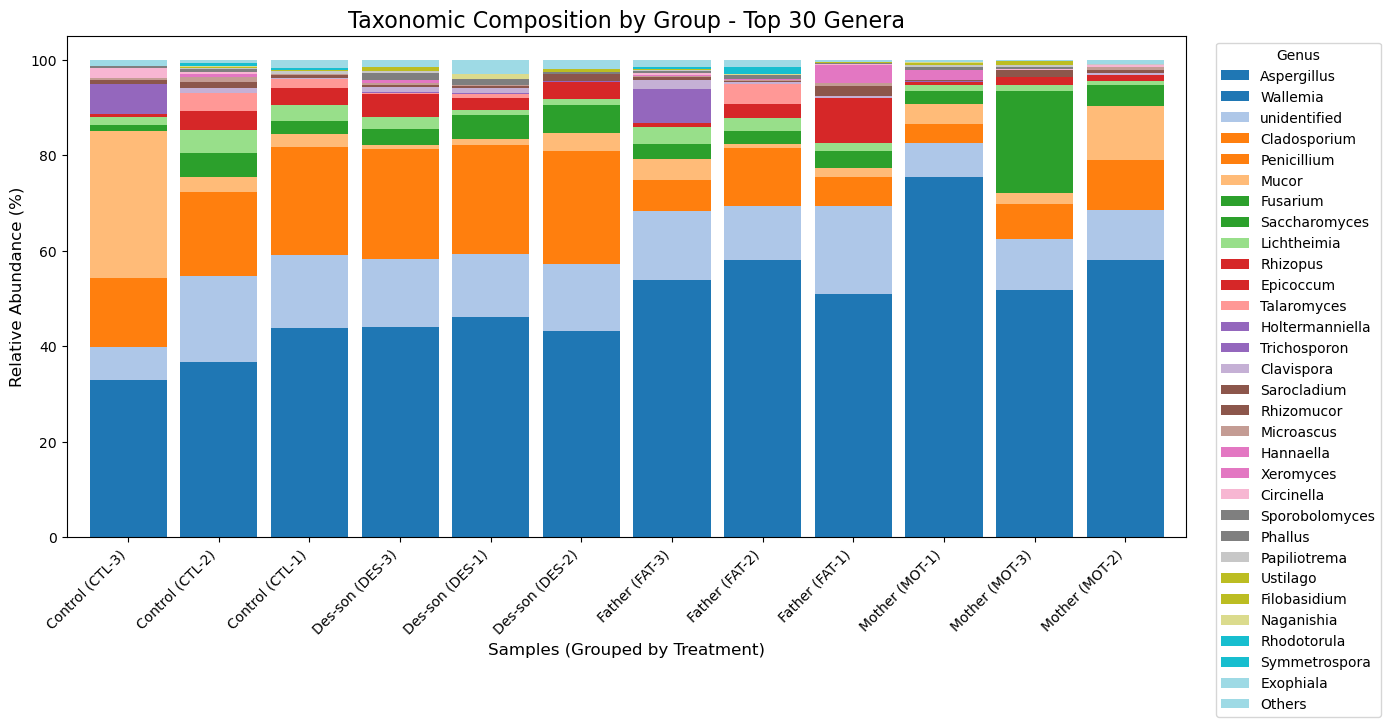

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define INPUT paths
stats_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/5_statistics'
counts_path = os.path.join(stats_dir, 'rarefied_genus_counts.csv')
meta_path = os.path.join(stats_dir, 'metadata_filtered.csv')

# 2. Load the tables
counts_rarefied = pd.read_csv(counts_path, index_col=0)
meta_df = pd.read_csv(meta_path, index_col=0)

# 3. IMPORTANT: Define your group column name here!
# Replace 'Treatment' with the exact column name from your metadata
group_col = 'Group'

# Sort metadata by the group column
meta_sorted = meta_df.sort_values(by=[group_col])

# Create a new label combining Group and Sample Name (e.g., "CTL (CTL-3)")
new_labels = meta_sorted[group_col].astype(str) + " (" + meta_sorted.index + ")"

# 4. Convert absolute counts to relative abundance (percentages)
rel_abund = counts_rarefied.div(counts_rarefied.sum(axis=1), axis=0) * 100

# 5. Identify the Top 10 most abundant genera
top_n = 30
top_genera = rel_abund.mean().nlargest(top_n).index

# 6. Create plot dataframe with Top 10 and 'Others'
plot_df = rel_abund[top_genera].copy()
plot_df['Others'] = rel_abund.drop(columns=top_genera).sum(axis=1)

# 7. Reorder plot_df to match the sorted metadata
plot_df = plot_df.loc[meta_sorted.index]
# Apply the new grouped labels to the X-axis
plot_df.index = new_labels

# 8. Define OUTPUT directory
plot_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/6_plots'
os.makedirs(plot_dir, exist_ok=True)

# 9. Plot Stacked Bar Chart
ax = plot_df.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='tab20', width=0.85)

# Formatting the plot
plt.title(f'Taxonomic Composition by Group - Top {top_n} Genera', fontsize=16)
plt.ylabel('Relative Abundance (%)', fontsize=12)
plt.xlabel('Samples (Grouped by Treatment)', fontsize=12)
plt.legend(title='Genus', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# 10. Save the plot
plot_path_png = os.path.join(plot_dir, 'taxonomic_composition_grouped.png')
plot_path_svg = os.path.join(plot_dir, 'taxonomic_composition_grouped.svg')

plt.savefig(plot_path_png, dpi=300, bbox_inches='tight')
plt.savefig(plot_path_svg, bbox_inches='tight')

print(f"Plot successfully saved to:\n{plot_dir}")
plt.show()

## Beta diversity analysis

/home/marcos/miniconda3/lib/python3.13/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:164: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(
/home/marcos/miniconda3/lib/python3.13/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:282: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -0.0027487420012166294 whereas the largest positive one is 0.22304996323519705.
  warn(


PERMANOVA Results:
Pseudo-F: 2.9967
p-value:  0.0010

Plot successfully saved to:
/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/6_plots


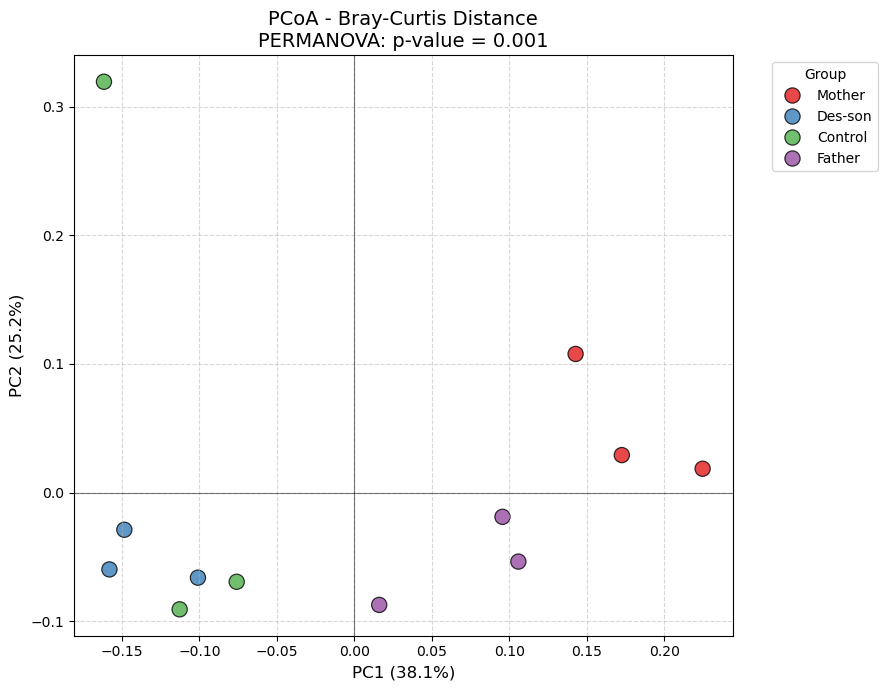

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa
from skbio.stats.distance import permanova

# 1. Define INPUT paths
stats_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/5_statistics'
counts_path = os.path.join(stats_dir, 'rarefied_genus_counts.csv')
meta_path = os.path.join(stats_dir, 'metadata_filtered.csv')

# Load the tables
counts_rarefied = pd.read_csv(counts_path, index_col=0)
meta_df = pd.read_csv(meta_path, index_col=0)

# IMPORTANT: Define your group column name here!
group_col = 'Group'

# 2. Calculate Bray-Curtis Distance Matrix
# We use .values to pass the raw numbers, and pass the sample names as ids
bc_dm = beta_diversity("braycurtis", counts_rarefied.values, ids=counts_rarefied.index)

# 3. Perform PCoA (Principal Coordinate Analysis)
bc_pcoa = pcoa(bc_dm)

# Extract the coordinates for PC1 and PC2
pcoa_df = bc_pcoa.samples[['PC1', 'PC2']].copy()
# Join with metadata to get the group labels for coloring the plot
pcoa_df = pcoa_df.join(meta_df[[group_col]])

# Extract the percentage of variance explained by each axis
prop_expl = bc_pcoa.proportion_explained

# 4. Perform PERMANOVA (Statistical test for Beta Diversity)
perm_result = permanova(bc_dm, meta_df, column=group_col, permutations=999)
p_val = perm_result['p-value']
pseudo_f = perm_result['test statistic']

print(f"PERMANOVA Results:")
print(f"Pseudo-F: {pseudo_f:.4f}")
print(f"p-value:  {p_val:.4f}\n")

# 5. Plot the PCoA
plt.figure(figsize=(9, 7))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue=group_col, 
    data=pcoa_df, 
    s=120,          # Marker size
    alpha=0.8,      # Transparency
    palette='Set1', # Color palette
    edgecolor='black'
)

# Formatting the plot
plt.title(f'PCoA - Bray-Curtis Distance\nPERMANOVA: p-value = {p_val:.3f}', fontsize=14)
plt.xlabel(f"PC1 ({prop_expl['PC1']*100:.1f}%)", fontsize=12)
plt.ylabel(f"PC2 ({prop_expl['PC2']*100:.1f}%)", fontsize=12)
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5) # X axis line
plt.axvline(0, color='black', linewidth=0.8, alpha=0.5) # Y axis line
plt.tight_layout()

# 6. Save the plot
plot_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/6_plots'
os.makedirs(plot_dir, exist_ok=True)

plot_path_png = os.path.join(plot_dir, 'pcoa_bray_curtis.png')
plot_path_svg = os.path.join(plot_dir, 'pcoa_bray_curtis.svg')

plt.savefig(plot_path_png, dpi=300, bbox_inches='tight')
plt.savefig(plot_path_svg, bbox_inches='tight')

print(f"Plot successfully saved to:\n{plot_dir}")

# Display the plot
plt.show()

## Alpha diversity analysis

Plotting order will be: ['CTL', 'MOT', 'DES', 'FAT']


/home/marcos/miniconda3/lib/python3.13/site-packages/skbio/util/_warning.py:42: DeprecationWarning: `observed_otus` was renamed to `sobs` in 0.6.0. The old name is kept as an alias but is deprecated.
  warn(message, warning)
/tmp/ipykernel_43025/3089804349.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Observed_Genera', data=meta_df, ax=axes[0], palette=palette, order=group_order, showfliers=False)
/tmp/ipykernel_43025/3089804349.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Shannon_Index', data=meta_df, ax=axes[1], palette=palette, order=group_order, showfliers=False)


Plot successfully saved to:
/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/6_plots/alpha_diversity_boxplots.png


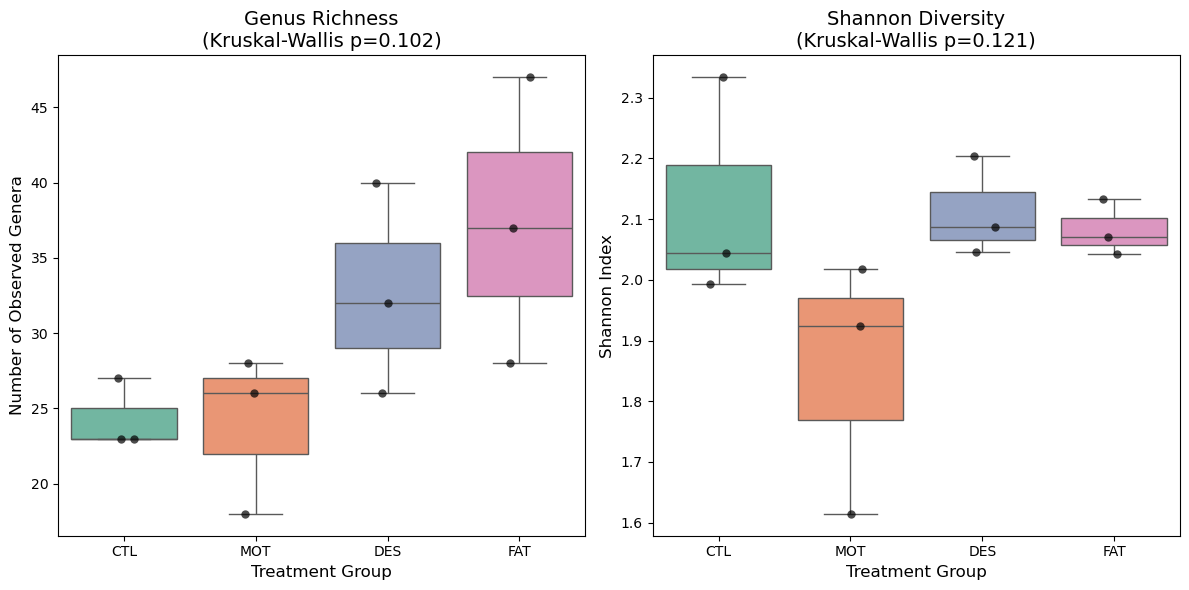

In [10]:
import os
import pandas as pd
import skbio
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal

# 1. Define INPUT paths
stats_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/5_statistics'
plot_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/6_plots'

counts_path = os.path.join(stats_dir, 'rarefied_genus_counts.csv')
meta_path = os.path.join(stats_dir, 'metadata_filtered.csv')

# Load the tables
counts_rarefied = pd.read_csv(counts_path, index_col=0)
meta_df = pd.read_csv(meta_path, index_col=0)

# Dynamically extract group names from the sample prefixes
meta_df['Group'] = [str(idx).split('-')[0] for idx in meta_df.index]
groups = list(meta_df['Group'].unique())

# --- NEW: Define the specific order of the groups for the plot ---
control_group = 'CTL'
# This creates a list with 'CTL' first, followed by the rest
group_order = [control_group] + [g for g in groups if g != control_group]
print(f"Plotting order will be: {group_order}")
# -----------------------------------------------------------------

# 2. Calculate Alpha Diversity
meta_df['Observed_Genera'] = skbio.diversity.alpha_diversity('observed_otus', counts_rarefied.values, counts_rarefied.index)
meta_df['Shannon_Index'] = skbio.diversity.alpha_diversity('shannon', counts_rarefied.values, counts_rarefied.index)

# 3. Statistical Test (Global Kruskal-Wallis)
group_data_obs = [meta_df[meta_df['Group'] == g]['Observed_Genera'] for g in group_order]
group_data_sha = [meta_df[meta_df['Group'] == g]['Shannon_Index'] for g in group_order]

stat_obs, p_obs = kruskal(*group_data_obs)
stat_sha, p_sha = kruskal(*group_data_sha)

# 4. Plot Alpha Diversity (Boxplots)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Palette matching the number of groups
palette = sns.color_palette("Set2", len(group_order))

# Plot 1: Richness (Observed Genera)
sns.boxplot(x='Group', y='Observed_Genera', data=meta_df, ax=axes[0], palette=palette, order=group_order, showfliers=False)
sns.stripplot(x='Group', y='Observed_Genera', data=meta_df, ax=axes[0], color='black', alpha=0.7, jitter=True, size=6, order=group_order)
axes[0].set_title(f'Genus Richness\n(Kruskal-Wallis p={p_obs:.3f})', fontsize=14)
axes[0].set_ylabel('Number of Observed Genera', fontsize=12)
axes[0].set_xlabel('Treatment Group', fontsize=12)

# Plot 2: Shannon Diversity
sns.boxplot(x='Group', y='Shannon_Index', data=meta_df, ax=axes[1], palette=palette, order=group_order, showfliers=False)
sns.stripplot(x='Group', y='Shannon_Index', data=meta_df, ax=axes[1], color='black', alpha=0.7, jitter=True, size=6, order=group_order)
axes[1].set_title(f'Shannon Diversity\n(Kruskal-Wallis p={p_sha:.3f})', fontsize=14)
axes[1].set_ylabel('Shannon Index', fontsize=12)
axes[1].set_xlabel('Treatment Group', fontsize=12)

plt.tight_layout()

# 5. Save the plots
plot_path_png = os.path.join(plot_dir, 'alpha_diversity_boxplots.png')
plt.savefig(plot_path_png, dpi=300, bbox_inches='tight')

print(f"Plot successfully saved to:\n{plot_path_png}")
plt.show()

# Bubble plots

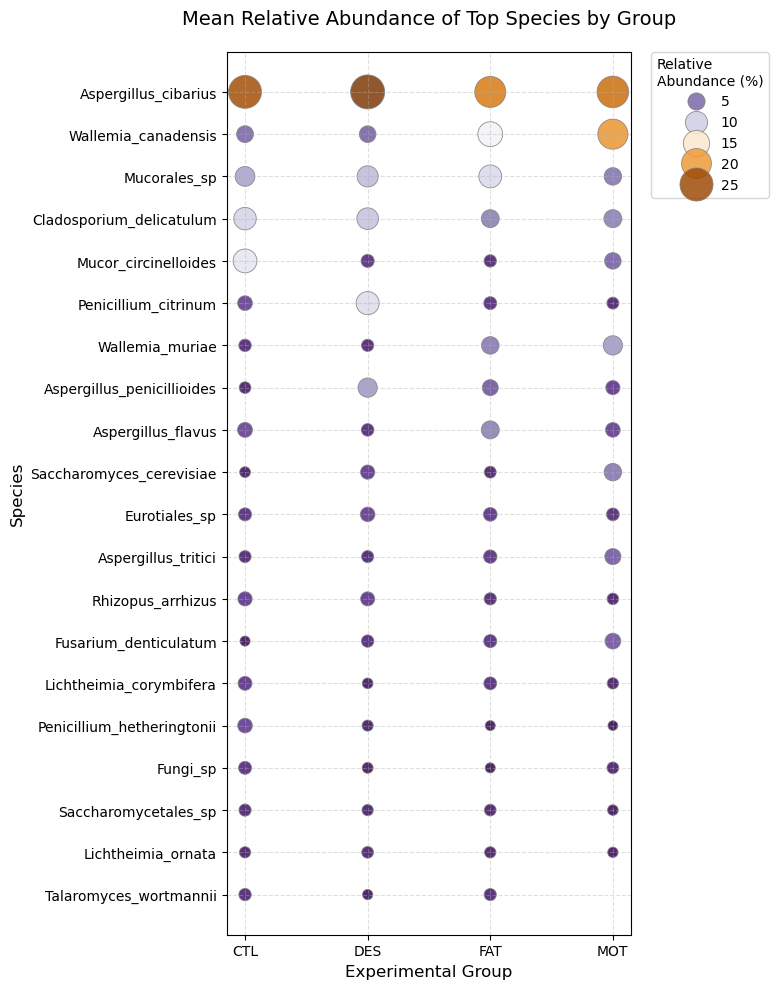

Abundance bubble plot successfully saved to:
/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/6_plots/bubble_abundance_plot.png


In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define paths
matrix_path = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/4_kma_taxa/otu_abundance_matrix_CLEAN.csv'
stats_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/5_statistics'
plot_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/6_plots'
meta_path = os.path.join(stats_dir, 'metadata_filtered.csv')

os.makedirs(plot_dir, exist_ok=True)
plot_path = os.path.join(plot_dir, 'bubble_abundance_plot.png')

# 2. Load data
otu_df = pd.read_csv(matrix_path)
meta_df = pd.read_csv(meta_path, index_col=0)

# Extract group names from the sample prefixes (e.g., 'CTL-1' -> 'CTL')
meta_df['Group'] = [str(idx).split('-')[0] for idx in meta_df.index]

# 3. Prepare Species Abundance
tax_cols = ['tax_id', 'superkingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species']
counts_df = otu_df.drop(columns=[c for c in tax_cols if c != 'species'])
counts_df = counts_df.groupby('species').sum(numeric_only=True).T

# Convert raw counts to Relative Abundance (percentages)
rel_abund = counts_df.div(counts_df.sum(axis=1), axis=0) * 100

# Select the top 20 most abundant species to keep the plot clean
top_species = rel_abund.mean().sort_values(ascending=False).head(20).index
rel_abund_top = rel_abund[top_species]

# 4. Merge with metadata and calculate the mean abundance per Group
common_samples = rel_abund_top.index.intersection(meta_df.index)
rel_abund_top = rel_abund_top.loc[common_samples]
meta_valid = meta_df.loc[common_samples]

# Add group column to abundance data
rel_abund_top['Group'] = meta_valid['Group']

# Calculate the mean relative abundance of each species per group
mean_abund_group = rel_abund_top.groupby('Group').mean()

# 5. Reshape data for seaborn (Melt into long format)
plot_df = mean_abund_group.reset_index().melt(
    id_vars='Group', 
    var_name='Species', 
    value_name='Mean_Abundance'
)

# Remove bubbles where abundance is exactly 0 to clean up the plot
plot_df = plot_df[plot_df['Mean_Abundance'] > 0]

# 6. Plotting
plt.figure(figsize=(8, 10))

# Create the bubble plot
sns.scatterplot(
    data=plot_df,
    x='Group',
    y='Species',
    size='Mean_Abundance',
    hue='Mean_Abundance',
    palette='PuOr_r',       # Purple-Orange colormap
    sizes=(50, 600),        # Minimum and maximum bubble sizes
    edgecolor='gray',
    alpha=0.85
)

# Customization
plt.legend(
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    borderaxespad=0, 
    title="Relative\nAbundance (%)"
)
plt.title('Mean Relative Abundance of Top Species by Group', pad=20, fontsize=14)
plt.xlabel('Experimental Group', fontsize=12)
plt.ylabel('Species', fontsize=12)

# Add a light grid
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()

# Save the plot to the specified directory
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

# --- DISPLAY ON SCREEN ---
plt.show()

# Close the plot to free memory
plt.close()

print(f"Abundance bubble plot successfully saved to:\n{plot_path}")

# Horizontal bar chart

Generating plot for group: MOT...


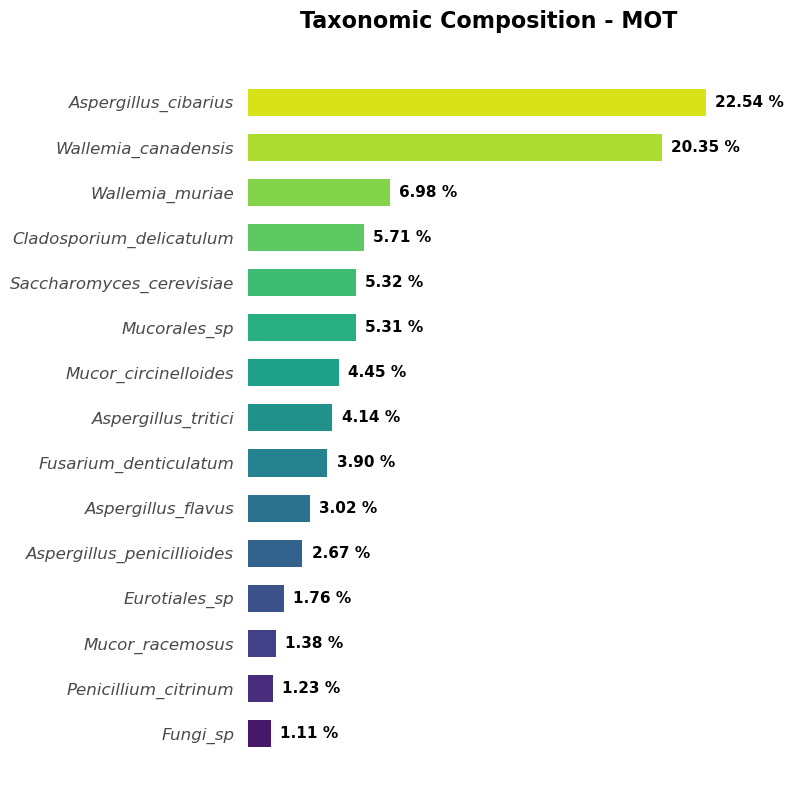

Saved: /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/6_plots/taxonomy/horizontal_bars_MOT.png

Generating plot for group: DES...


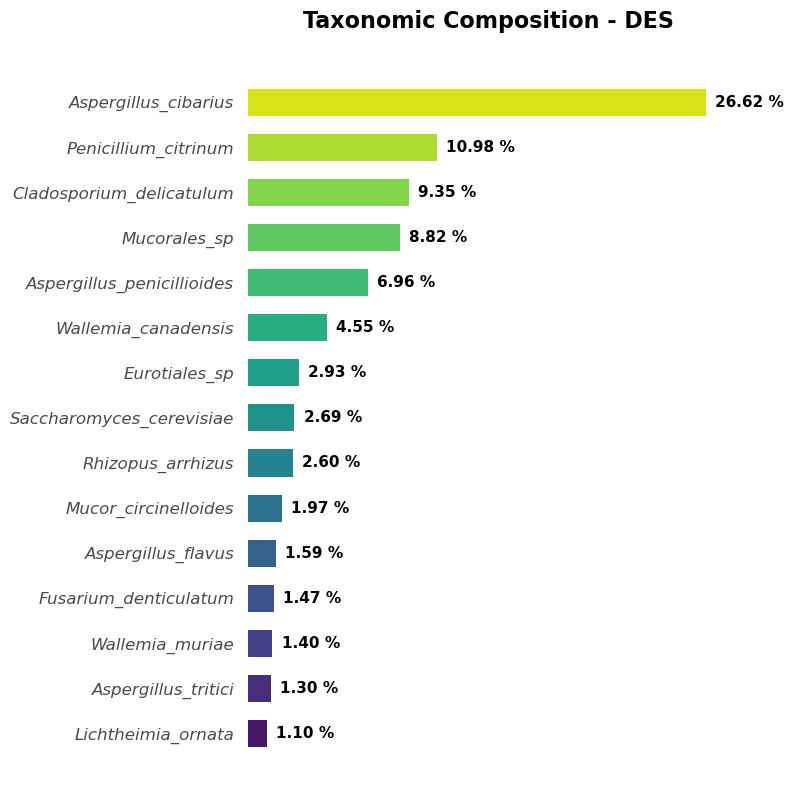

Saved: /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/6_plots/taxonomy/horizontal_bars_DES.png

Generating plot for group: CTL...


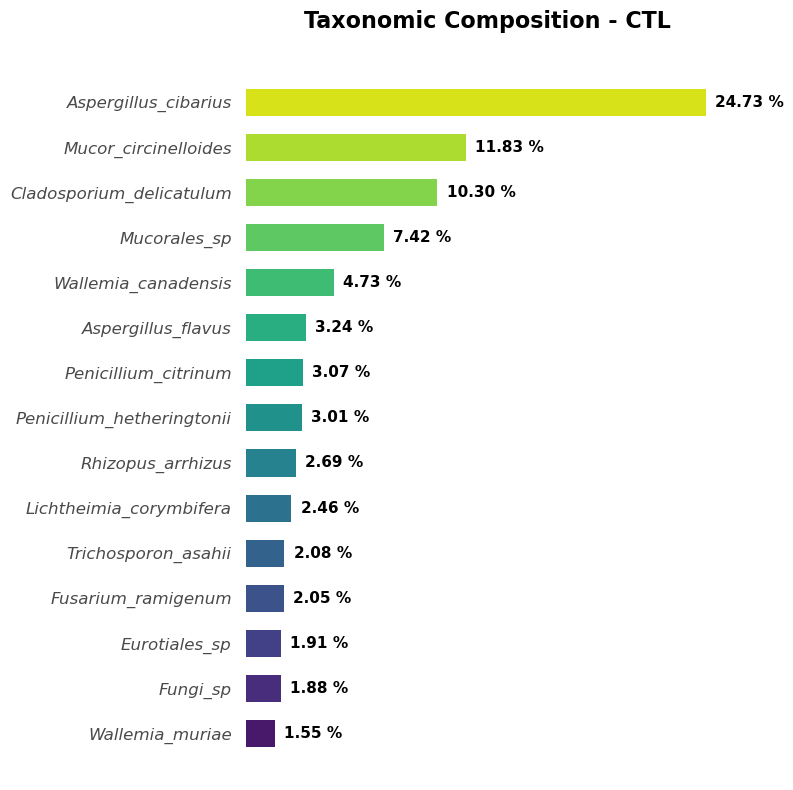

Saved: /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/6_plots/taxonomy/horizontal_bars_CTL.png

Generating plot for group: FAT...


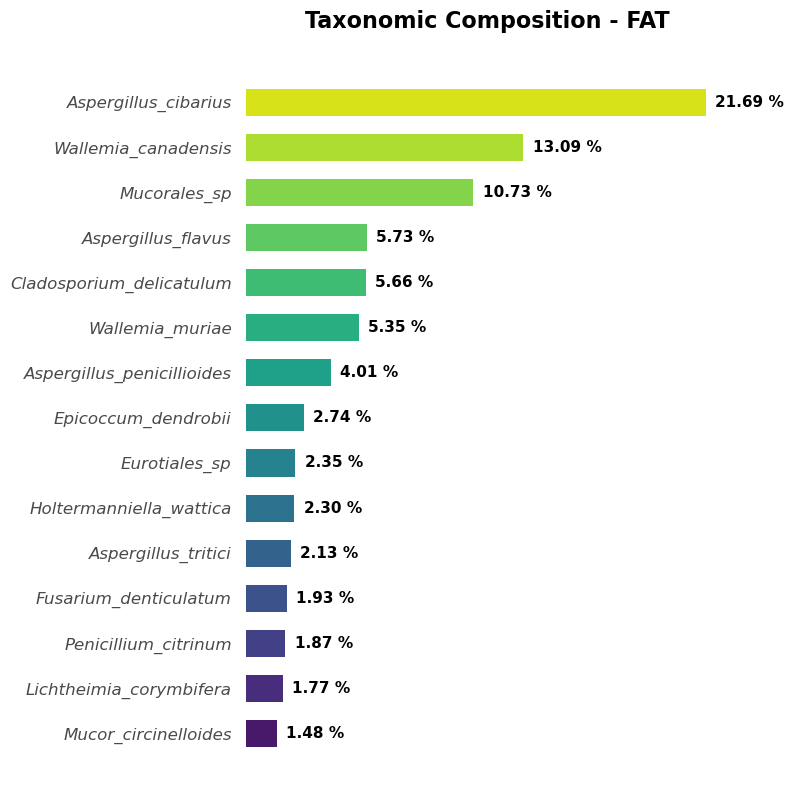

Saved: /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/6_plots/taxonomy/horizontal_bars_FAT.png

All group plots have been generated!


In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define paths
matrix_path = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/4_kma_taxa/otu_abundance_matrix_CLEAN.csv'
stats_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/5_statistics'
plot_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/6_plots/taxonomy'
meta_path = os.path.join(stats_dir, 'metadata_filtered.csv')

os.makedirs(plot_dir, exist_ok=True)

# 2. Load Data
otu_df = pd.read_csv(matrix_path)
meta_df = pd.read_csv(meta_path, index_col=0)

# Extract group names from the sample prefixes (e.g., 'CTL-1' -> 'CTL')
meta_df['Group'] = [str(idx).split('-')[0] for idx in meta_df.index]
unique_groups = meta_df['Group'].unique()

# 3. Prepare Species Abundance
tax_cols = ['tax_id', 'superkingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species']
counts_df = otu_df.drop(columns=[c for c in tax_cols if c != 'species'])
counts_df = counts_df.groupby('species').sum(numeric_only=True).T

# Align samples between abundance matrix and metadata
common_samples = counts_df.index.intersection(meta_df.index)
counts_df = counts_df.loc[common_samples]
meta_df = meta_df.loc[common_samples]

# Convert raw counts to Relative Abundance per sample (0 - 100%)
rel_abund = counts_df.div(counts_df.sum(axis=1), axis=0) * 100
rel_abund['Group'] = meta_df['Group']

# 4. Loop through each group and generate a custom plot
for group in unique_groups:
    print(f"Generating plot for group: {group}...")
    
    # Filter data for the current group and drop the 'Group' text column
    group_data = rel_abund[rel_abund['Group'] == group].drop(columns='Group')
    
    # Calculate the mean relative abundance across samples in this group
    mean_abund = group_data.mean(axis=0)
    
    # Get the top 15 most abundant species for THIS specific group
    top_species = mean_abund.sort_values(ascending=False).head(15)
    
    # Drop any species that might have 0% abundance (just in case)
    top_species = top_species[top_species > 0]
    
    # Sort ascending so the largest bar appears at the TOP of the horizontal plot
    top_species = top_species.sort_values(ascending=True)
    
    # 5. Plotting
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Use viridis colormap, matching the amount of bars
    colors = sns.color_palette("viridis", len(top_species))
    
    bars = ax.barh(top_species.index, top_species.values, color=colors, height=0.6)
    
    # 6. Aesthetic Customizations
    # Remove all borders (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Remove the X-axis completely
    ax.set_xticks([])
    
    # Remove Y-axis tick marks, but keep the labels
    ax.tick_params(axis='y', length=0, pad=10, labelsize=12)
    
    # Italicize bacterial names (keeping 'Unclassified' normal)
    for label in ax.get_yticklabels():
        text = label.get_text()
        if text not in ['Unclassified', 'Unknown', 'Não identificado']:
            label.set_fontstyle('italic')
        label.set_color('#4a4a4a') # Dark gray text
        
    # Add the percentage text at the end of each bar
    for bar in bars:
        width = bar.get_width()
        label_x = width + (top_species.max() * 0.02) 
        label_y = bar.get_y() + bar.get_height() / 2
        
        ax.text(
            label_x, 
            label_y, 
            f'{width:.2f} %', 
            va='center', 
            fontweight='bold', 
            fontsize=11,
            color='black'
        )
        
    plt.title(f'Taxonomic Composition - {group}', fontsize=16, pad=20, fontweight='bold')
    plt.tight_layout()
    
    # Save specific plot for the group
    plot_path = os.path.join(plot_dir, f'horizontal_bars_{group}.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    
    # Display the plot in the notebook
    plt.show()
    plt.close()
    
    print(f"Saved: {plot_path}\n")

print("All group plots have been generated!")

## Differential abundance analysis

In [13]:
import os
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# 1. Define paths
matrix_path = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/4_kma_taxa/otu_abundance_matrix_CLEAN.csv'
stats_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/5_statistics'
plot_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its_kma/6_plots'
meta_path = os.path.join(stats_dir, 'metadata_filtered.csv')

os.makedirs(plot_dir, exist_ok=True)

# 2. Load RAW Matrix and Metadata
otu_df = pd.read_csv(matrix_path)
tax_cols = ['tax_id', 'superkingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species']
counts_raw = otu_df.drop(columns=[c for c in tax_cols if c != 'genus'])
counts_raw = counts_raw.groupby('genus').sum(numeric_only=True).T
meta_df = pd.read_csv(meta_path, index_col=0)
counts_raw = counts_raw.loc[meta_df.index]

# 3. Dynamically extract group names from the sample prefixes (e.g., 'CTL-1' -> 'CTL')
meta_df['Group'] = [str(idx).split('-')[0] for idx in meta_df.index]
unique_groups = meta_df['Group'].unique()

print(f"Setup complete. Detected groups: {unique_groups}")

# Generate all unique pairs of groups (combinations of 2)
all_pairs = list(combinations(unique_groups, 2))
print(f"Total comparisons to run: {len(all_pairs)}\n")

# Prepare relative abundance with pseudocount
counts_pseudo = counts_raw + 1
rel_abund = counts_pseudo.div(counts_pseudo.sum(axis=1), axis=0)

# 4. Loop through all pairs
for group1, group2 in all_pairs:
    print(f"=========================================")
    print(f"Testing: {group1} vs {group2}")
    
    samples_g1 = meta_df[meta_df['Group'] == group1].index
    samples_g2 = meta_df[meta_df['Group'] == group2].index
    
    df_g1 = rel_abund.loc[samples_g1]
    df_g2 = rel_abund.loc[samples_g2]
    
    results = []
    for genus in rel_abund.columns:
        stat, p_val = mannwhitneyu(df_g1[genus], df_g2[genus], alternative='two-sided')
        mean_g1 = df_g1[genus].mean()
        mean_g2 = df_g2[genus].mean()
        
        # Log2FC > 0 means increased in Group2. Log2FC < 0 means increased in Group1.
        log2fc = np.log2(mean_g2 / mean_g1)
        
        results.append({
            'Genus': genus,
            f'Mean_{group1}': mean_g1,
            f'Mean_{group2}': mean_g2,
            'Log2FC': log2fc,
            'p_value': p_val
        })

    da_df = pd.DataFrame(results).set_index('Genus').dropna()
    
    # FDR Correction
    da_df['FDR_q_value'] = multipletests(da_df['p_value'], method='fdr_bh')[1]
    
    # Filter Significant
    significant_genera = da_df[(da_df['FDR_q_value'] < 0.05) & (da_df['Log2FC'].abs() > 1)].copy()
    significant_genera = significant_genera.sort_values(by='Log2FC', ascending=False)
    
    # Save CSV for this pair
    da_out_path = os.path.join(stats_dir, f'differential_abundance_{group2}_vs_{group1}.csv')
    da_df.to_csv(da_out_path)
    
    # Plot if significant results exist
    if significant_genera.empty:
        print(f"No significant genera found for {group1} vs {group2}.\n")
    else:
        print(f"Found {len(significant_genera)} significant genera! Generating plot...\n")
        
        plt.figure(figsize=(10, max(4, len(significant_genera) * 0.4)))
        
        # Colors: Green if enriched in group2, Red if enriched in group1
        colors = ['#2ca02c' if x > 0 else '#d62728' for x in significant_genera['Log2FC']]
        
        sns.barplot(x=significant_genera['Log2FC'], y=significant_genera.index, palette=colors)
        
        plt.title(f'Differentially Abundant Genera\nGreen = Enriched in {group2} | Red = Enriched in {group1}', fontsize=14)
        plt.xlabel(f'Log2 Fold Change ({group2} / {group1})', fontsize=12)
        plt.ylabel('Genus', fontsize=12)
        plt.axvline(0, color='black', linewidth=1)
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        
        plot_path_png = os.path.join(plot_dir, f'da_barplot_{group2}_vs_{group1}.png')
        plt.savefig(plot_path_png, dpi=300, bbox_inches='tight')
        plt.close() # Close plot to prevent massive notebook scrolling

Setup complete. Detected groups: <StringArray>
['MOT', 'DES', 'CTL', 'FAT']
Length: 4, dtype: str
Total comparisons to run: 6

Testing: MOT vs DES
No significant genera found for MOT vs DES.

Testing: MOT vs CTL
No significant genera found for MOT vs CTL.

Testing: MOT vs FAT
No significant genera found for MOT vs FAT.

Testing: DES vs CTL
No significant genera found for DES vs CTL.

Testing: DES vs FAT
No significant genera found for DES vs FAT.

Testing: CTL vs FAT
No significant genera found for CTL vs FAT.



# 16S

## Taxonomic composition of the samples

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define INPUT paths (loading the saved tables)
stats_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/5_statistics/kda'
counts_path = os.path.join(stats_dir, 'rarefied_genus_counts.csv')

# Load the counts matrix (index_col=0 keeps the sample names as rows)
counts_rarefied = pd.read_csv(counts_path, index_col=0)

# 2. Define OUTPUT directory for plots
plot_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/6_plots/kda'
os.makedirs(plot_dir, exist_ok=True)

# 3. Convert absolute counts to relative abundance (percentages)
rel_abund = counts_rarefied.div(counts_rarefied.sum(axis=1), axis=0) * 100

# 4. Identify the Top 10 most abundant genera
top_n = 30
top_genera = rel_abund.mean().nlargest(top_n).index

# 5. Create a new dataframe with Top 10 and group the rest into 'Others'
plot_df = rel_abund[top_genera].copy()
plot_df['Others'] = rel_abund.drop(columns=top_genera).sum(axis=1)

# Sort samples alphabetically
plot_df = plot_df.sort_index()

# 6. Plot Stacked Bar Chart
ax = plot_df.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='tab20')

# Formatting the plot
plt.title(f'Taxonomic Composition - Top {top_n} Genera', fontsize=16)
plt.ylabel('Relative Abundance (%)', fontsize=12)
plt.xlabel('Samples', fontsize=12)
plt.legend(title='Genus', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# 7. Save the plot in PNG and SVG
plot_path_png = os.path.join(plot_dir, f'taxonomic_composition_top{top_n}.png')
plot_path_svg = os.path.join(plot_dir, f'taxonomic_composition_top{top_n}.svg')

plt.savefig(plot_path_png, dpi=300, bbox_inches='tight')
plt.savefig(plot_path_svg, bbox_inches='tight')

print(f"Plot successfully saved to:\n{plot_dir}")

# Display the plot in the notebook
plt.show()

## Separation of the samples by groups

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define INPUT paths
stats_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/5_statistics/kda'
counts_path = os.path.join(stats_dir, 'rarefied_genus_counts.csv')
meta_path = os.path.join(stats_dir, 'metadata_filtered.csv')

# 2. Load the tables
counts_rarefied = pd.read_csv(counts_path, index_col=0)
meta_df = pd.read_csv(meta_path, index_col=0)

# 3. IMPORTANT: Define your group column name here!
# Replace 'Treatment' with the exact column name from your metadata
group_col = 'Group'

# Sort metadata by the group column
meta_sorted = meta_df.sort_values(by=[group_col])

# Create a new label combining Group and Sample Name (e.g., "CTL (CTL-3)")
new_labels = meta_sorted[group_col].astype(str) + " (" + meta_sorted.index + ")"

# 4. Convert absolute counts to relative abundance (percentages)
rel_abund = counts_rarefied.div(counts_rarefied.sum(axis=1), axis=0) * 100

# 5. Identify the Top 10 most abundant genera
top_n = 30
top_genera = rel_abund.mean().nlargest(top_n).index

# 6. Create plot dataframe with Top 10 and 'Others'
plot_df = rel_abund[top_genera].copy()
plot_df['Others'] = rel_abund.drop(columns=top_genera).sum(axis=1)

# 7. Reorder plot_df to match the sorted metadata
plot_df = plot_df.loc[meta_sorted.index]
# Apply the new grouped labels to the X-axis
plot_df.index = new_labels

# 8. Define OUTPUT directory
plot_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/6_plots/kda'
os.makedirs(plot_dir, exist_ok=True)

# 9. Plot Stacked Bar Chart
ax = plot_df.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='tab20', width=0.85)

# Formatting the plot
plt.title(f'Taxonomic Composition by Group - Top {top_n} Genera', fontsize=16)
plt.ylabel('Relative Abundance (%)', fontsize=12)
plt.xlabel('Samples (Grouped by Treatment)', fontsize=12)
plt.legend(title='Genus', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# 10. Save the plot
plot_path_png = os.path.join(plot_dir, 'taxonomic_composition_grouped.png')
plot_path_svg = os.path.join(plot_dir, 'taxonomic_composition_grouped.svg')

plt.savefig(plot_path_png, dpi=300, bbox_inches='tight')
plt.savefig(plot_path_svg, bbox_inches='tight')

print(f"Plot successfully saved to:\n{plot_dir}")
plt.show()

## Beta diversity analysis

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa
from skbio.stats.distance import permanova

# 1. Define INPUT paths
stats_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/5_statistics/kda'
counts_path = os.path.join(stats_dir, 'rarefied_genus_counts.csv')
meta_path = os.path.join(stats_dir, 'metadata_filtered.csv')

# Load the tables
counts_rarefied = pd.read_csv(counts_path, index_col=0)
meta_df = pd.read_csv(meta_path, index_col=0)

# IMPORTANT: Define your group column name here!
group_col = 'Group'

# 2. Calculate Bray-Curtis Distance Matrix
# We use .values to pass the raw numbers, and pass the sample names as ids
bc_dm = beta_diversity("braycurtis", counts_rarefied.values, ids=counts_rarefied.index)

# 3. Perform PCoA (Principal Coordinate Analysis)
bc_pcoa = pcoa(bc_dm)

# Extract the coordinates for PC1 and PC2
pcoa_df = bc_pcoa.samples[['PC1', 'PC2']].copy()
# Join with metadata to get the group labels for coloring the plot
pcoa_df = pcoa_df.join(meta_df[[group_col]])

# Extract the percentage of variance explained by each axis
prop_expl = bc_pcoa.proportion_explained

# 4. Perform PERMANOVA (Statistical test for Beta Diversity)
perm_result = permanova(bc_dm, meta_df, column=group_col, permutations=999)
p_val = perm_result['p-value']
pseudo_f = perm_result['test statistic']

print(f"PERMANOVA Results:")
print(f"Pseudo-F: {pseudo_f:.4f}")
print(f"p-value:  {p_val:.4f}\n")

# 5. Plot the PCoA
plt.figure(figsize=(9, 7))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue=group_col, 
    data=pcoa_df, 
    s=120,          # Marker size
    alpha=0.8,      # Transparency
    palette='Set1', # Color palette
    edgecolor='black'
)

# Formatting the plot
plt.title(f'PCoA - Bray-Curtis Distance\nPERMANOVA: p-value = {p_val:.3f}', fontsize=14)
plt.xlabel(f"PC1 ({prop_expl['PC1']*100:.1f}%)", fontsize=12)
plt.ylabel(f"PC2 ({prop_expl['PC2']*100:.1f}%)", fontsize=12)
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5) # X axis line
plt.axvline(0, color='black', linewidth=0.8, alpha=0.5) # Y axis line
plt.tight_layout()

# 6. Save the plot
plot_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/6_plots/kda'
os.makedirs(plot_dir, exist_ok=True)

plot_path_png = os.path.join(plot_dir, 'pcoa_bray_curtis.png')
plot_path_svg = os.path.join(plot_dir, 'pcoa_bray_curtis.svg')

plt.savefig(plot_path_png, dpi=300, bbox_inches='tight')
plt.savefig(plot_path_svg, bbox_inches='tight')

print(f"Plot successfully saved to:\n{plot_dir}")

# Display the plot
plt.show()

## Alpha diversity analysis

In [ ]:
import os
import pandas as pd
import skbio
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal

# 1. Define INPUT paths
stats_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/5_statistics/kda'
plot_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/6_plots/kda'

counts_path = os.path.join(stats_dir, 'rarefied_genus_counts.csv')
meta_path = os.path.join(stats_dir, 'metadata_filtered.csv')

# Load the tables
counts_rarefied = pd.read_csv(counts_path, index_col=0)
meta_df = pd.read_csv(meta_path, index_col=0)

# Dynamically extract group names from the sample prefixes
meta_df['Group'] = [str(idx).split('-')[0] for idx in meta_df.index]
groups = list(meta_df['Group'].unique())

# --- NEW: Define the specific order of the groups for the plot ---
control_group = 'CTL'
# This creates a list with 'CTL' first, followed by the rest
group_order = [control_group] + [g for g in groups if g != control_group]
print(f"Plotting order will be: {group_order}")
# -----------------------------------------------------------------

# 2. Calculate Alpha Diversity
meta_df['Observed_Genera'] = skbio.diversity.alpha_diversity('observed_otus', counts_rarefied.values, counts_rarefied.index)
meta_df['Shannon_Index'] = skbio.diversity.alpha_diversity('shannon', counts_rarefied.values, counts_rarefied.index)

# 3. Statistical Test (Global Kruskal-Wallis)
group_data_obs = [meta_df[meta_df['Group'] == g]['Observed_Genera'] for g in group_order]
group_data_sha = [meta_df[meta_df['Group'] == g]['Shannon_Index'] for g in group_order]

stat_obs, p_obs = kruskal(*group_data_obs)
stat_sha, p_sha = kruskal(*group_data_sha)

# 4. Plot Alpha Diversity (Boxplots)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Palette matching the number of groups
palette = sns.color_palette("Set2", len(group_order))

# Plot 1: Richness (Observed Genera)
sns.boxplot(x='Group', y='Observed_Genera', data=meta_df, ax=axes[0], palette=palette, order=group_order, showfliers=False)
sns.stripplot(x='Group', y='Observed_Genera', data=meta_df, ax=axes[0], color='black', alpha=0.7, jitter=True, size=6, order=group_order)
axes[0].set_title(f'Genus Richness\n(Kruskal-Wallis p={p_obs:.3f})', fontsize=14)
axes[0].set_ylabel('Number of Observed Genera', fontsize=12)
axes[0].set_xlabel('Treatment Group', fontsize=12)

# Plot 2: Shannon Diversity
sns.boxplot(x='Group', y='Shannon_Index', data=meta_df, ax=axes[1], palette=palette, order=group_order, showfliers=False)
sns.stripplot(x='Group', y='Shannon_Index', data=meta_df, ax=axes[1], color='black', alpha=0.7, jitter=True, size=6, order=group_order)
axes[1].set_title(f'Shannon Diversity\n(Kruskal-Wallis p={p_sha:.3f})', fontsize=14)
axes[1].set_ylabel('Shannon Index', fontsize=12)
axes[1].set_xlabel('Treatment Group', fontsize=12)

plt.tight_layout()

# 5. Save the plots
plot_path_png = os.path.join(plot_dir, 'alpha_diversity_boxplots.png')
plt.savefig(plot_path_png, dpi=300, bbox_inches='tight')

print(f"Plot successfully saved to:\n{plot_path_png}")
plt.show()

# Bubble dot plot

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define paths
matrix_path = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/4_kma_taxa/ncbi/otu_abundance_matrix_CLEAN.csv'
stats_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/5_statistics/kda'
plot_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/6_plots/abundance'
meta_path = os.path.join(stats_dir, 'metadata_filtered.csv')

os.makedirs(plot_dir, exist_ok=True)
plot_path = os.path.join(plot_dir, 'bubble_abundance_plot.png')

# 2. Load data
otu_df = pd.read_csv(matrix_path)
meta_df = pd.read_csv(meta_path, index_col=0)

# Extract group names from the sample prefixes (e.g., 'CTL-1' -> 'CTL')
meta_df['Group'] = [str(idx).split('-')[0] for idx in meta_df.index]

# 3. Prepare Species Abundance
tax_cols = ['tax_id', 'superkingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species']
counts_df = otu_df.drop(columns=[c for c in tax_cols if c != 'species'])
counts_df = counts_df.groupby('species').sum(numeric_only=True).T

# Convert raw counts to Relative Abundance (percentages)
rel_abund = counts_df.div(counts_df.sum(axis=1), axis=0) * 100

# Select the top 20 most abundant species to keep the plot clean
top_species = rel_abund.mean().sort_values(ascending=False).head(20).index
rel_abund_top = rel_abund[top_species]

# 4. Merge with metadata and calculate the mean abundance per Group
common_samples = rel_abund_top.index.intersection(meta_df.index)
rel_abund_top = rel_abund_top.loc[common_samples]
meta_valid = meta_df.loc[common_samples]

# Add group column to abundance data
rel_abund_top['Group'] = meta_valid['Group']

# Calculate the mean relative abundance of each species per group
mean_abund_group = rel_abund_top.groupby('Group').mean()

# 5. Reshape data for seaborn (Melt into long format)
plot_df = mean_abund_group.reset_index().melt(
    id_vars='Group', 
    var_name='Species', 
    value_name='Mean_Abundance'
)

# Remove bubbles where abundance is exactly 0 to clean up the plot
plot_df = plot_df[plot_df['Mean_Abundance'] > 0]

# 6. Plotting
plt.figure(figsize=(8, 10))

# Create the bubble plot
sns.scatterplot(
    data=plot_df,
    x='Group',
    y='Species',
    size='Mean_Abundance',
    hue='Mean_Abundance',
    palette='PuOr_r',       # Purple-Orange colormap
    sizes=(50, 600),        # Minimum and maximum bubble sizes
    edgecolor='gray',
    alpha=0.85
)

# Customization
plt.legend(
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    borderaxespad=0, 
    title="Relative\nAbundance (%)"
)
plt.title('Mean Relative Abundance of Top Species by Group', pad=20, fontsize=14)
plt.xlabel('Experimental Group', fontsize=12)
plt.ylabel('Species', fontsize=12)

# Add a light grid
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()

# Save the plot to the specified directory
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

# --- DISPLAY ON SCREEN ---
plt.show()

# Close the plot to free memory
plt.close()

print(f"Abundance bubble plot successfully saved to:\n{plot_path}")

# Horizontal bar chart

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define paths
matrix_path = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/4_kma_taxa/ncbi/otu_abundance_matrix_CLEAN.csv'
stats_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/5_statistics/kda'
plot_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/6_plots/taxonomy'
meta_path = os.path.join(stats_dir, 'metadata_filtered.csv')

os.makedirs(plot_dir, exist_ok=True)

# 2. Load Data
otu_df = pd.read_csv(matrix_path)
meta_df = pd.read_csv(meta_path, index_col=0)

# Extract group names from the sample prefixes (e.g., 'CTL-1' -> 'CTL')
meta_df['Group'] = [str(idx).split('-')[0] for idx in meta_df.index]
unique_groups = meta_df['Group'].unique()

# 3. Prepare Species Abundance
tax_cols = ['tax_id', 'superkingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species']
counts_df = otu_df.drop(columns=[c for c in tax_cols if c != 'species'])
counts_df = counts_df.groupby('species').sum(numeric_only=True).T

# Align samples between abundance matrix and metadata
common_samples = counts_df.index.intersection(meta_df.index)
counts_df = counts_df.loc[common_samples]
meta_df = meta_df.loc[common_samples]

# Convert raw counts to Relative Abundance per sample (0 - 100%)
rel_abund = counts_df.div(counts_df.sum(axis=1), axis=0) * 100
rel_abund['Group'] = meta_df['Group']

# 4. Loop through each group and generate a custom plot
for group in unique_groups:
    print(f"Generating plot for group: {group}...")
    
    # Filter data for the current group and drop the 'Group' text column
    group_data = rel_abund[rel_abund['Group'] == group].drop(columns='Group')
    
    # Calculate the mean relative abundance across samples in this group
    mean_abund = group_data.mean(axis=0)
    
    # Get the top 15 most abundant species for THIS specific group
    top_species = mean_abund.sort_values(ascending=False).head(15)
    
    # Drop any species that might have 0% abundance (just in case)
    top_species = top_species[top_species > 0]
    
    # Sort ascending so the largest bar appears at the TOP of the horizontal plot
    top_species = top_species.sort_values(ascending=True)
    
    # 5. Plotting
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Use viridis colormap, matching the amount of bars
    colors = sns.color_palette("viridis", len(top_species))
    
    bars = ax.barh(top_species.index, top_species.values, color=colors, height=0.6)
    
    # 6. Aesthetic Customizations
    # Remove all borders (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Remove the X-axis completely
    ax.set_xticks([])
    
    # Remove Y-axis tick marks, but keep the labels
    ax.tick_params(axis='y', length=0, pad=10, labelsize=12)
    
    # Italicize bacterial names (keeping 'Unclassified' normal)
    for label in ax.get_yticklabels():
        text = label.get_text()
        if text not in ['Unclassified', 'Unknown', 'Não identificado']:
            label.set_fontstyle('italic')
        label.set_color('#4a4a4a') # Dark gray text
        
    # Add the percentage text at the end of each bar
    for bar in bars:
        width = bar.get_width()
        label_x = width + (top_species.max() * 0.02) 
        label_y = bar.get_y() + bar.get_height() / 2
        
        ax.text(
            label_x, 
            label_y, 
            f'{width:.2f} %', 
            va='center', 
            fontweight='bold', 
            fontsize=11,
            color='black'
        )
        
    plt.title(f'Taxonomic Composition - {group}', fontsize=16, pad=20, fontweight='bold')
    plt.tight_layout()
    
    # Save specific plot for the group
    plot_path = os.path.join(plot_dir, f'horizontal_bars_{group}.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    
    # Display the plot in the notebook
    plt.show()
    plt.close()
    
    print(f"Saved: {plot_path}\n")

print("All group plots have been generated!")

## Differential abundance analysis

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# 1. Define paths
matrix_path = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/4_kma_taxa/ncbi/otu_abundance_matrix_CLEAN.csv'
stats_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/5_statistics/kda'
plot_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/6_plots/kda'
meta_path = os.path.join(stats_dir, 'metadata_filtered.csv')

os.makedirs(plot_dir, exist_ok=True)

# 2. Load RAW Matrix and Metadata
otu_df = pd.read_csv(matrix_path)
tax_cols = ['tax_id', 'superkingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species']
counts_raw = otu_df.drop(columns=[c for c in tax_cols if c != 'genus'])
counts_raw = counts_raw.groupby('genus').sum(numeric_only=True).T
meta_df = pd.read_csv(meta_path, index_col=0)
counts_raw = counts_raw.loc[meta_df.index]

# 3. Dynamically extract group names from the sample prefixes (e.g., 'CTL-1' -> 'CTL')
meta_df['Group'] = [str(idx).split('-')[0] for idx in meta_df.index]
unique_groups = meta_df['Group'].unique()

print(f"Setup complete. Detected groups: {unique_groups}")

# Generate all unique pairs of groups (combinations of 2)
all_pairs = list(combinations(unique_groups, 2))
print(f"Total comparisons to run: {len(all_pairs)}\n")

# Prepare relative abundance with pseudocount
counts_pseudo = counts_raw + 1
rel_abund = counts_pseudo.div(counts_pseudo.sum(axis=1), axis=0)

# 4. Loop through all pairs
for group1, group2 in all_pairs:
    print(f"=========================================")
    print(f"Testing: {group1} vs {group2}")
    
    samples_g1 = meta_df[meta_df['Group'] == group1].index
    samples_g2 = meta_df[meta_df['Group'] == group2].index
    
    df_g1 = rel_abund.loc[samples_g1]
    df_g2 = rel_abund.loc[samples_g2]
    
    results = []
    for genus in rel_abund.columns:
        stat, p_val = mannwhitneyu(df_g1[genus], df_g2[genus], alternative='two-sided')
        mean_g1 = df_g1[genus].mean()
        mean_g2 = df_g2[genus].mean()
        
        # Log2FC > 0 means increased in Group2. Log2FC < 0 means increased in Group1.
        log2fc = np.log2(mean_g2 / mean_g1)
        
        results.append({
            'Genus': genus,
            f'Mean_{group1}': mean_g1,
            f'Mean_{group2}': mean_g2,
            'Log2FC': log2fc,
            'p_value': p_val
        })

    da_df = pd.DataFrame(results).set_index('Genus').dropna()
    
    # FDR Correction
    da_df['FDR_q_value'] = multipletests(da_df['p_value'], method='fdr_bh')[1]
    
    # Filter Significant
    significant_genera = da_df[(da_df['FDR_q_value'] < 0.05) & (da_df['Log2FC'].abs() > 1)].copy()
    significant_genera = significant_genera.sort_values(by='Log2FC', ascending=False)
    
    # Save CSV for this pair
    da_out_path = os.path.join(stats_dir, f'differential_abundance_{group2}_vs_{group1}.csv')
    da_df.to_csv(da_out_path)
    
    # Plot if significant results exist
    if significant_genera.empty:
        print(f"No significant genera found for {group1} vs {group2}.\n")
    else:
        print(f"Found {len(significant_genera)} significant genera! Generating plot...\n")
        
        plt.figure(figsize=(10, max(4, len(significant_genera) * 0.4)))
        
        # Colors: Green if enriched in group2, Red if enriched in group1
        colors = ['#2ca02c' if x > 0 else '#d62728' for x in significant_genera['Log2FC']]
        
        sns.barplot(x=significant_genera['Log2FC'], y=significant_genera.index, palette=colors)
        
        plt.title(f'Differentially Abundant Genera\nGreen = Enriched in {group2} | Red = Enriched in {group1}', fontsize=14)
        plt.xlabel(f'Log2 Fold Change ({group2} / {group1})', fontsize=12)
        plt.ylabel('Genus', fontsize=12)
        plt.axvline(0, color='black', linewidth=1)
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        
        plot_path_png = os.path.join(plot_dir, f'da_barplot_{group2}_vs_{group1}.png')
        plt.savefig(plot_path_png, dpi=300, bbox_inches='tight')
        plt.close() # Close plot to prevent massive notebook scrolling

## Heatmap

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define paths
stats_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/5_statistics/ancombc'
plot_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/6_plots'
os.makedirs(plot_dir, exist_ok=True)

# 2. Load and merge ANCOM-BC2 results
df_ctl = pd.read_csv(os.path.join(stats_dir, 'ancombc_vs_CTL.csv'))
df_pair = pd.read_csv(os.path.join(stats_dir, 'ancombc_pairwise_tratamentos.csv'))
df_all = pd.merge(df_ctl, df_pair, on='taxon', how='outer')

# 3. Identify Log2FC (lfc) and q-value (q) columns
lfc_cols = [col for col in df_all.columns if col.startswith('lfc_')]
qval_cols = [col.replace('lfc_', 'q_') for col in lfc_cols]

# 4. Filter for significance (keep genus if at least one comparison has q < 0.05)
significance_threshold = 0.05
df_sig = df_all[df_all[qval_cols].lt(significance_threshold).any(axis=1)].copy()

# --- SAFETY CHECK ADDED ---
if df_sig.empty:
    print(f"No significant differential abundance found (q-value < {significance_threshold}).")
    print("The heatmap cannot be generated because the filtered dataset is empty.")
else:
    df_sig.set_index('taxon', inplace=True)
    
    # 5. Extract matrices for plotting
    lfc_matrix = df_sig[lfc_cols].copy()
    qval_matrix = df_sig[qval_cols].copy()
    
    # Clean up column names for the plot (e.g., 'lfc_GroupFAT' -> 'FAT vs CTL')
    clean_names = []
    for col in lfc_cols:
        name = col.replace('lfc_Group', '').replace('Group', '')
        if '_' in name:
            clean_names.append(name.replace('_', ' vs '))
        else:
            clean_names.append(f"{name} vs CTL")
            
    lfc_matrix.columns = clean_names
    qval_matrix.columns = clean_names
    
    # Create an annotation matrix ('*' if significant, else empty string)
    annot_matrix = qval_matrix.map(lambda q: '*' if q < significance_threshold else '')
    
    # 6. Plot Heatmap
    plt.figure(figsize=(10, max(5, len(df_sig) * 0.4)))
    
    # Balance colors symmetrically around zero
    max_val = abs(lfc_matrix.values).max()
    
    sns.heatmap(
        lfc_matrix, 
        cmap='vlag', 
        center=0, 
        vmin=-max_val, 
        vmax=max_val,
        annot=annot_matrix, 
        fmt='', 
        cbar_kws={'label': 'Log2 Fold Change'},
        linewidths=0.5, 
        linecolor='black'
    )
    
    # English formatting for publication
    plt.title('Differential Abundance (ANCOM-BC2)\n* q-value < 0.05', fontsize=14, pad=15)
    plt.xlabel('Comparisons', fontsize=12)
    plt.ylabel('Genus', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    # 7. Save plot
    plot_path_png = os.path.join(plot_dir, 'ancombc_heatmap.png')
    plot_path_svg = os.path.join(plot_dir, 'ancombc_heatmap.svg')
    plt.savefig(plot_path_png, dpi=300, bbox_inches='tight')
    plt.savefig(plot_path_svg, bbox_inches='tight')
    
    print(f"Heatmap saved to:\n{plot_dir}")
    plt.show()

⚠️ No significant differential abundance found (q-value < 0.05).
The heatmap cannot be generated because the filtered dataset is empty.
